# VoxIntel — 04: Full Baseline ASR Evaluation

Goal: this notebook is **pure analysis**, not modeling. We take the same
pretrained `facebook/wav2vec2-base-960h` baseline from notebook 03 and run
it over the **entire** validation set (not just 100 samples), then dig into
where it succeeds and fails:

- Overall WER / CER
- Per-intent WER
- Per-scenario WER
- WER vs. utterance duration (long vs. short)
- Supporting plots for all of the above

Establish the baseline transcription error profile that will later be analyzed for downstream error propagation.

No fine-tuning happens here — that's notebook 05. This notebook's job is to
produce the baseline reference numbers and error patterns that notebook 06
(fine-tuned evaluation) will be compared against, cell-for-cell.

`transcribe()` is copied here unchanged from notebook 03, not imported —
intentional duplication per the project's research → refactor workflow.
Once it's proven stable across this notebook and notebook 05, that's the
signal to move it into `src/asr/inference.py`.


## Cell 0 — Make sure `src` is importable

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Cell 1 — Imports

In [2]:
import random

import torch
import pandas as pd
import numpy as np
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoProcessor, Wav2Vec2ForCTC

from src.data import SLURPDataset
from src.utils.audio import load_audio, get_duration
from src.utils.text import normalize_text

sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

c:\Users\ACER\anaconda3\envs\torch26\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 — Load Full Validation Set

Same split as notebook 03, on purpose — this is the whole point of having
fixed that choice there.


In [4]:
val_set = SLURPDataset(
    split="validation",
    root_dir="C:\\Users\\ACER\\OneDrive\\Desktop\\VoxIntel\\data\\raw\\slurp"
)

print(f"Validation set size: {len(val_set)}")


Validation set size: 8690


## Cell 3 — Load Wav2Vec2 (same baseline model as notebook 03)

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

processor = AutoProcessor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")
model.to(DEVICE)
model.eval()

print("Model loaded:", model.config.model_type)

Using device: cuda


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 541.32it/s, Materializing param=wav2vec2.feature_projection.projection.weight]                         
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: wav2vec2


## Cell 4 — `transcribe(audio_path)`

Copied verbatim from notebook 03. If you change this function, change it
in both places for now (or better: run 03 and 04 side by side to notice
the moment it's worth deduplicating into `src/`).


In [6]:
def transcribe(audio_path, processor=processor, model=model, device=DEVICE):
    """Run baseline Wav2Vec2 CTC inference on one audio file.

    Returns the greedy-decoded transcript as a string. Returns None if the
    audio can't be loaded (missing/corrupted file).
    """
    try:
        waveform, sr = load_audio(audio_path, target_sr=16_000)
    except Exception as e:
        print(f"Failed to load {audio_path}: {e}")
        return None

    inputs = processor(waveform, sampling_rate=sr, return_tensors="pt")
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        logits = model(input_values).logits

    predicted_ids = torch.argmax(logits, dim=-1)
    prediction = processor.batch_decode(predicted_ids)[0]
    return prediction

## Cell 5 — Run Inference on the Entire Validation Set

This is ~thousands of files, one at a time on CPU — expect this to take a
while (could be tens of minutes depending on your hardware; much faster on
GPU). Two safety features:

- `EVAL_LIMIT`: set to a small number (e.g. `50`) first to sanity-check
  everything runs end-to-end before committing to the full pass. Set to
  `None` for the real full-validation run.
- Result caching: if `reports/full_validation_predictions.csv` already
  exists, this cell loads it instead of re-running inference, unless
  `FORCE_RERUN = True`.


In [7]:
EVAL_LIMIT = None    # set to e.g. 50 for a quick sanity-check pass first
FORCE_RERUN = False

output_dir = PROJECT_ROOT / "reports"
output_dir.mkdir(exist_ok=True)
predictions_path = output_dir / "full_validation_predictions.csv"

if predictions_path.exists() and not FORCE_RERUN:
    print(f"Found cached predictions at {predictions_path}, loading instead of re-running.")
    results_df = pd.read_csv(predictions_path)
else:
    eval_samples = list(val_set)
    if EVAL_LIMIT is not None:
        eval_samples = eval_samples[:EVAL_LIMIT]

    results = []
    for s in tqdm(eval_samples, desc="Transcribing full validation set"):
        pred = transcribe(s["audio_path"])
        duration = get_duration(s["audio_path"])
        results.append({
            "audio_path": s["audio_path"],
            "ground_truth": s["transcript"],
            "prediction": pred,
            "intent": s["intent"],
            "scenario": s["scenario"],
            "duration_sec": duration,
        })

    results_df = pd.DataFrame(results)
    results_df.to_csv(predictions_path, index=False)
    print(f"Saved {len(results_df)} predictions to {predictions_path}")

print(f"Total rows: {len(results_df)}")
results_df.head()

Transcribing full validation set: 100%|██████████| 8690/8690 [05:20<00:00, 27.15it/s]


Saved 8690 predictions to c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\full_validation_predictions.csv
Total rows: 8690


,audio_path,ground_truth,prediction,intent,scenario,duration_sec
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,qa_currency,qa,3.200000
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,qa_currency,qa,3.199562
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,email_query,email,3.712000
3,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,email_query,email,3.647500
4,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,email_query,email,2.880000


## Cell 6 — Clean and Score

Drop failed transcriptions, normalize text (same normalization as notebook
03 — lowercase, punctuation stripped), and compute per-sample WER so every
later analysis (per-intent, per-scenario, per-duration) can just group and
aggregate this one column.


In [8]:
scored_df = results_df.dropna(subset=["prediction"]).copy()
n_failed = len(results_df) - len(scored_df)
if n_failed:
    print(f"Skipping {n_failed} samples with failed transcription")

scored_df["ground_truth_norm"] = scored_df["ground_truth"].apply(normalize_text)
scored_df["prediction_norm"] = scored_df["prediction"].apply(normalize_text)

def sample_wer(ref, hyp):
    try:
        return jiwer.wer(ref, hyp)
    except Exception:
        return np.nan

def sample_cer(ref, hyp):
    try:
        return jiwer.cer(ref, hyp)
    except Exception:
        return np.nan

scored_df["wer"] = [
    sample_wer(r, h) for r, h in zip(scored_df["ground_truth_norm"], scored_df["prediction_norm"])
]
scored_df["cer"] = [
    sample_cer(r, h) for r, h in zip(scored_df["ground_truth_norm"], scored_df["prediction_norm"])
]

scored_df[["ground_truth", "prediction", "wer", "cer", "duration_sec"]].head()


,ground_truth,prediction,wer,cer,duration_sec
0,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,0.444444,0.18750,3.200000
1,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,0.666667,0.37500,3.199562
2,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,0.428571,0.15625,3.712000
3,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,0.714286,0.28125,3.647500
4,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,0.285714,0.15625,2.880000


## Cell 7 — Overall WER / CER

Two numbers reported: **corpus-level** (the standard way — total edit
distance over total words/chars across the whole set) and the **mean of
per-sample WER/CER** (easier to relate to the per-intent/per-scenario
breakdowns below, but technically a different statistic — corpus-level WER
is not literally the average of per-sentence WERs). Both are worth having;
corpus-level is what you'd report as "the" baseline WER.


In [9]:
corpus_wer = jiwer.wer(
    list(scored_df["ground_truth_norm"]), list(scored_df["prediction_norm"])
)
corpus_cer = jiwer.cer(
    list(scored_df["ground_truth_norm"]), list(scored_df["prediction_norm"])
)

print("Corpus-level WER:", round(corpus_wer, 4))
print("Corpus-level CER:", round(corpus_cer, 4))
print()
print("Mean per-sample WER:", round(scored_df["wer"].mean(), 4))
print("Mean per-sample CER:", round(scored_df["cer"].mean(), 4))
print("Median per-sample WER:", round(scored_df["wer"].median(), 4))

Corpus-level WER: 0.5843
Corpus-level CER: 0.3087

Mean per-sample WER: 0.6231
Mean per-sample CER: 0.3265
Median per-sample WER: 0.6


## Cell 8 — Per-Intent WER

Computed as **corpus-level WER within each intent group** (not a mean of
per-sample WERs — same reasoning as Cell 7), so each intent's number is
methodologically consistent with the overall figure. Filtering out intents
with fewer than 5 samples in this split, since WER on 1-2 examples is not a
meaningful per-class estimate (and you already know from the dataset report
that several intents are extremely rare).


In [10]:
def corpus_wer_per_group(df, group_col, min_count=5):
    rows = []
    for key, group in df.groupby(group_col):
        if len(group) < min_count:
            continue
        wer = jiwer.wer(list(group["ground_truth_norm"]), list(group["prediction_norm"]))
        cer = jiwer.cer(list(group["ground_truth_norm"]), list(group["prediction_norm"]))
        rows.append({group_col: key, "wer": wer, "cer": cer, "count": len(group)})
    return pd.DataFrame(rows).sort_values("wer", ascending=False)


intent_wer_df = corpus_wer_per_group(scored_df, "intent", min_count=5)
print(f"{len(intent_wer_df)} intents with >=5 samples in validation")
intent_wer_df.head(15)

66 intents with >=5 samples in validation


,intent,wer,cer,count
19,general_greet,1.029412,0.546218,17
31,iot_wemo_on,0.868421,0.445355,13
5,audio_volume_up,0.731771,0.430208,101
53,quirky,0.729730,0.303571,26
1,alarm_remove,0.708972,0.351090,87
28,iot_hue_lighton,0.700000,0.417160,11
39,music_settings,0.693182,0.396078,22
22,hue_lightoff,0.688889,0.418803,9
45,play_radio,0.679476,0.351183,235
26,iot_hue_lightdim,0.675362,0.356978,79


### Plot — Per-intent WER (worst 20 vs. best 20)

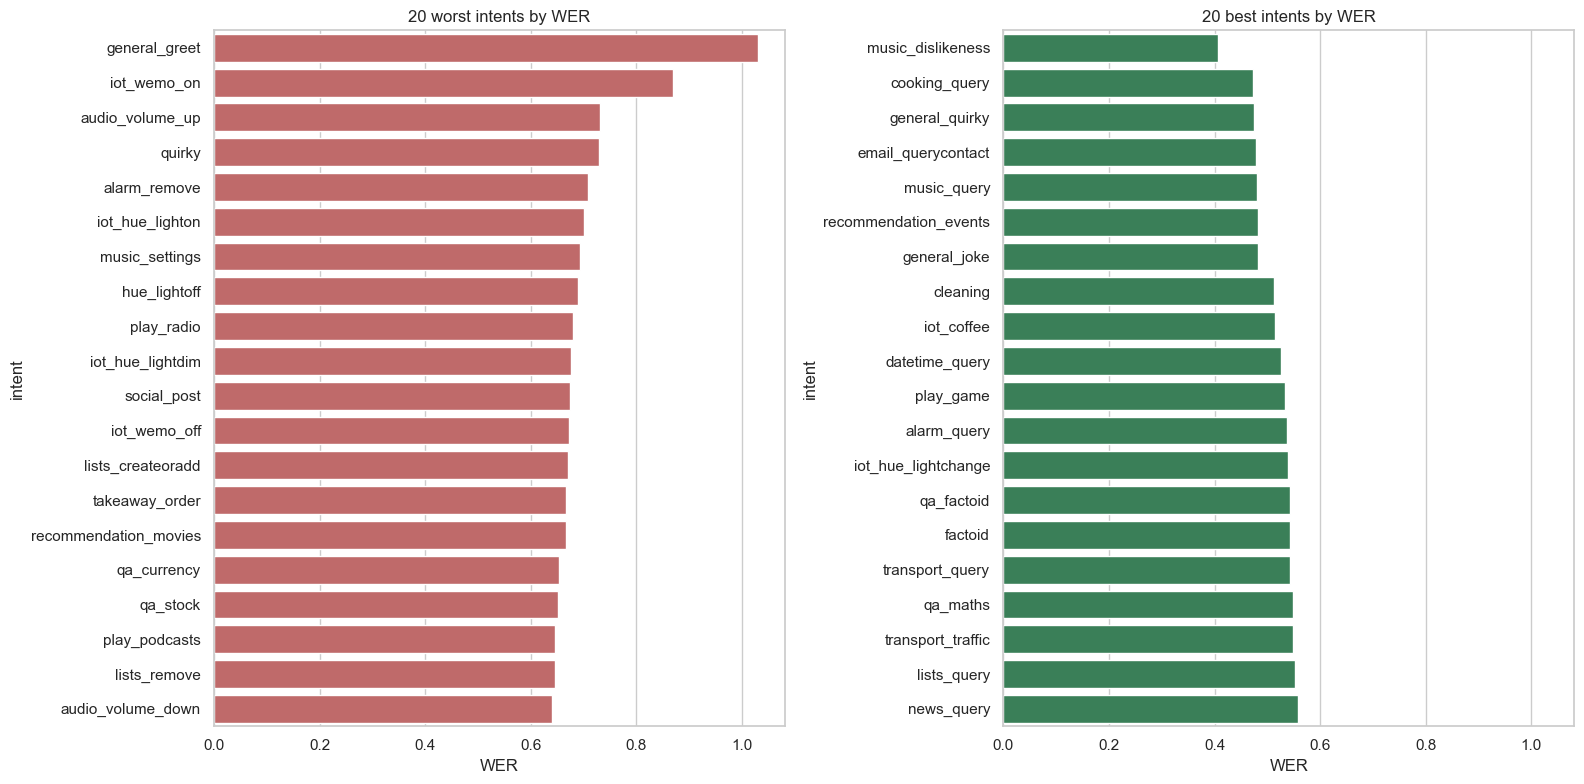

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

worst_20 = intent_wer_df.head(20)
best_20 = intent_wer_df.tail(20).sort_values("wer")

sns.barplot(data=worst_20, y="intent", x="wer", ax=axes[0], color="indianred")
axes[0].set_title("20 worst intents by WER")
axes[0].set_xlabel("WER")

sns.barplot(data=best_20, y="intent", x="wer", ax=axes[1], color="seagreen")
axes[1].set_title("20 best intents by WER")
axes[1].set_xlabel("WER")

plt.tight_layout()
plt.show()


## Cell 9 — Per-Scenario WER

Only 18 scenarios (vs. 101 intents), so this one's readable as a single
full bar chart rather than a worst/best split.


In [12]:
scenario_wer_df = corpus_wer_per_group(scored_df, "scenario", min_count=1)
scenario_wer_df


,scenario,wer,cer,count
1,audio,0.654255,0.363744,285
15,takeaway,0.647701,0.324027,186
14,social,0.638582,0.324921,270
0,alarm,0.614883,0.303514,366
5,email,0.610977,0.337654,597
8,lists,0.607558,0.331758,440
7,iot,0.607311,0.341072,483
11,play,0.602779,0.309587,1260
17,weather,0.601628,0.302302,509
2,calendar,0.588048,0.303900,1146


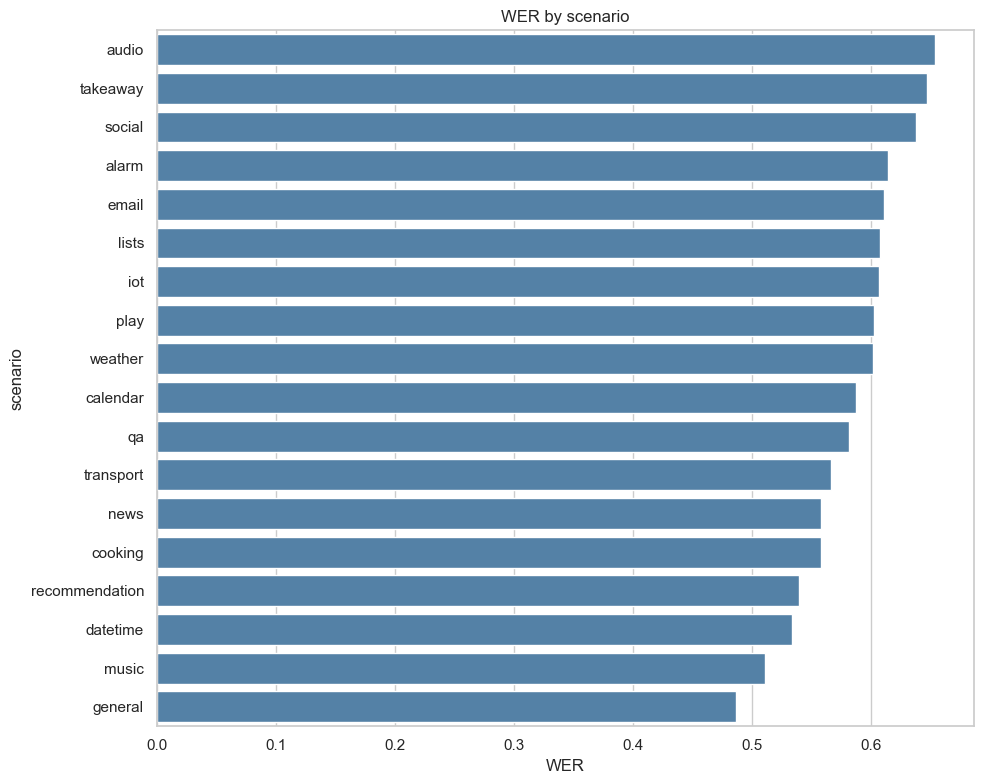

In [13]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=scenario_wer_df.sort_values("wer", ascending=False),
    y="scenario", x="wer", color="steelblue"
)
plt.xlabel("WER")
plt.title("WER by scenario")
plt.tight_layout()
plt.show()


## Cell 10 — Long vs. Short Utterances

Bucketing by duration and checking whether WER degrades on longer clips
(more opportunity for errors to compound) or, alternatively, on very short
clips (less context for the model). Buckets are quartile-based so each
group has a comparable sample size regardless of the overall duration
distribution shape.


In [14]:
scored_df["duration_bucket"] = pd.qcut(
    scored_df["duration_sec"], q=4, labels=["Q1 (shortest)", "Q2", "Q3", "Q4 (longest)"]
)

duration_bucket_wer = corpus_wer_per_group(scored_df, "duration_bucket", min_count=1)
# corpus_wer_per_group groups alphabetically; reorder to bucket order
bucket_order = ["Q1 (shortest)", "Q2", "Q3", "Q4 (longest)"]
duration_bucket_wer["duration_bucket"] = pd.Categorical(
    duration_bucket_wer["duration_bucket"], categories=bucket_order, ordered=True
)
duration_bucket_wer = duration_bucket_wer.sort_values("duration_bucket")

print("Duration range per bucket:")
print(scored_df.groupby("duration_bucket")["duration_sec"].agg(["min", "max", "mean", "count"]))
print()
duration_bucket_wer


C:\Users\ACER\AppData\Local\Temp\ipykernel_25636\120240149.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for key, group in df.groupby(group_col):


Duration range per bucket:
                      min        max      mean  count
duration_bucket                                      
Q1 (shortest)    0.511938   1.984000  1.604698   2242
Q2               2.020188   2.624000  2.331150   2187
Q3               2.631687   3.455563  3.013697   2105
Q4 (longest)     3.456000  13.165750  4.548926   2156



C:\Users\ACER\AppData\Local\Temp\ipykernel_25636\399822533.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(scored_df.groupby("duration_bucket")["duration_sec"].agg(["min", "max", "mean", "count"]))


,duration_bucket,wer,cer,count
0,Q1 (shortest),0.654814,0.371201,2242
1,Q2,0.590964,0.308987,2187
2,Q3,0.579077,0.302425,2105
3,Q4 (longest),0.553155,0.286717,2156


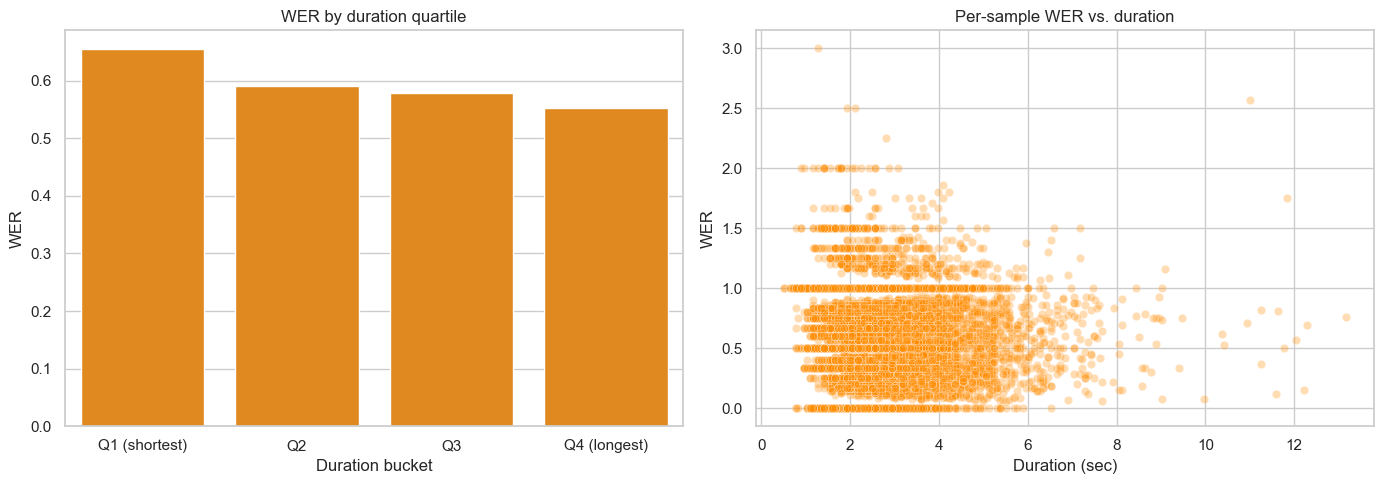

Correlation between duration and WER: -0.094


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=duration_bucket_wer, x="duration_bucket", y="wer", ax=axes[0], color="darkorange")
axes[0].set_title("WER by duration quartile")
axes[0].set_xlabel("Duration bucket")
axes[0].set_ylabel("WER")

sns.scatterplot(
    data=scored_df, x="duration_sec", y="wer", alpha=0.3, ax=axes[1], color="darkorange"
)
axes[1].set_title("Per-sample WER vs. duration")
axes[1].set_xlabel("Duration (sec)")
axes[1].set_ylabel("WER")

plt.tight_layout()
plt.show()

correlation = scored_df["duration_sec"].corr(scored_df["wer"])
print(f"Correlation between duration and WER: {correlation:.3f}")


## Cell 11 — Summary Table

One place to see everything computed above at a glance.


In [16]:
print("=" * 60)
print("BASELINE ASR EVALUATION SUMMARY (full validation set)")
print("=" * 60)
print(f"Samples evaluated       : {len(scored_df)} / {len(results_df)} (failed: {n_failed})")
print(f"Corpus WER              : {corpus_wer:.4f}")
print(f"Corpus CER              : {corpus_cer:.4f}")
print()
print(f"Worst intent (WER)      : {intent_wer_df.iloc[0]['intent']} ({intent_wer_df.iloc[0]['wer']:.3f}, n={intent_wer_df.iloc[0]['count']})")
print(f"Best intent (WER)       : {intent_wer_df.iloc[-1]['intent']} ({intent_wer_df.iloc[-1]['wer']:.3f}, n={intent_wer_df.iloc[-1]['count']})")
print()
print(f"Worst scenario (WER)    : {scenario_wer_df.sort_values('wer', ascending=False).iloc[0]['scenario']}")
print(f"Best scenario (WER)     : {scenario_wer_df.sort_values('wer').iloc[0]['scenario']}")
print()
print(f"Duration vs WER correlation: {correlation:.3f}")
print(duration_bucket_wer[["duration_bucket", "wer", "count"]].to_string(index=False))


BASELINE ASR EVALUATION SUMMARY (full validation set)
Samples evaluated       : 8690 / 8690 (failed: 0)
Corpus WER              : 0.5843
Corpus CER              : 0.3087

Worst intent (WER)      : general_greet (1.029, n=17)
Best intent (WER)       : music_dislikeness (0.406, n=5)

Worst scenario (WER)    : audio
Best scenario (WER)     : general

Duration vs WER correlation: -0.094
duration_bucket      wer  count
  Q1 (shortest) 0.654814   2242
             Q2 0.590964   2187
             Q3 0.579077   2105
   Q4 (longest) 0.553155   2156


# Conclusion

This notebook presents a comprehensive evaluation of the pretrained
`facebook/wav2vec2-base-960h` model on the SLURP validation set.

The baseline ASR system was evaluated using both corpus-level and
sample-level metrics, including Word Error Rate (WER) and Character
Error Rate (CER). In addition to overall performance, transcription
quality was analyzed across individual intents, scenarios, and audio
duration groups.

The evaluation shows that ASR performance is not uniform across the
dataset. Certain intent categories and scenarios exhibit noticeably
higher transcription errors, while others are recognized much more
accurately. The duration-based analysis also provides insight into how
utterance length influences recognition quality.

Overall, this notebook establishes a reliable baseline against which all
future ASR experiments will be compared. The metrics obtained here will
serve as the reference point for evaluating improvements achieved
through fine-tuning.